# Train a MNIST model with PyTorch and deploy to Azure Functions

---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook.

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

---

## Contents

  - [Overview](#Overview)
  - [Prerequisites](#Prerequisites)
  - [Setup](#Setup)
    - [Install Dependencies](#Install-Dependencies)
  - [Parameters](#Parameters)
  - [Training](#Training)
    - [The Training Script (train.py)](#The-Training-Script-(train.py))
    - [Dataset](#Dataset)
    - [The ModelTrainer Class](#The-ModelTrainer-Class)
    - [Calling the train method](#Calling-the-train-method)
  - [Export Model to ONNX](#Export-Model-to-ONNX)
  - [Package the Model](#Package-the-Model)
  - [Deploy the model](#Deploy-the-model)
    - [Install the Azure CLI and utility libraries](#Install-the-Azure-CLI-and-utility-libraries)
    - [Sign in to your Azure Account](#Sign-in-to-your-Azure-Account)
    - [Setup](#Setup)
    - [Create a Resource Group](#Create-a-Resource-Group)
    - [Create Storage Account](#Create-Storage-Account)
    - [Create the function app](#Create-the-function-app)
    - [Deploy our zip package to the function app](#Deploy-our-zip-package-to-the-function-app)
  - [Test Inference](#Test-Inference)
    - [Normalize and Visualize a random set of test images](#Normalize-and-Visualize-a-random-set-of-test-images)
    - [Run inference by invoking the Azure function URL](#Run-inference-by-invoking-the-Azure-function-URL)
  - [Clean Up](#Clean-Up)
  - [Conclusion](#Conclusion)

## Overview

This notebook demonstrates how to train a model using Amazon SageMaker and deploy it to Azure Functions. This approach is beneficial if you use AWS services for ML for its most comprehensive set of features, yet you need to run your model in another cloud provider in situations for example, you might have acquired a company that was already running on a different cloud provider, or you may have a workload that generates value from unique capabilities provided by AWS. Another example is independent software vendors (ISV) that make their products and services available in different cloud platforms to benefit their end customers. Or an organization may be operating in a Region where a primary cloud provider is not available, and in order to meet the data sovereignty or data residency requirements, they can use a secondary cloud provider.

In this notebook, we use PyTorch with Amazon SageMaker to train a model to classify handwritten digits. Once trained, we export the model to an ONNX format and deploy it to Azure functions. To train the model, we use the popular MNIST dataset for training the model. 
MNIST is a subset of a larger set available from NIST. It contains 70000 labelled grayscale images each of size 28x28 pixels. The dataset is split into sets of 60000 training images and 10000 test images.
---

## Prerequisites
* Access to Azure and credentials for a service principal that has permissions to create and manage Azure Functions and associate resources


## Setup

### Install Dependencies

In [1]:
# [exec-copy] deps preinstalled in .v3test-venv; pip install disabled


## Parameters

Start with setting up basic configuration we would use throughout this notebook. This includes - 
* The Execution role that provides SageMaker permissions to access the input training and test data in the Amazon S3 bucket in your account.
* The default region for SageMaker
* The bucket and prefix where would be store the input dataset and where SageMaker would store the output model artifacts

In [2]:
import boto3
import os
from sagemaker.core.helper.session_helper import Session, get_execution_role

execution_role = "arn:aws:iam::729646638167:role/SageMakerRole"  # [exec-copy] explicit role (get_execution_role only works inside SageMaker)
region = boto3.Session().region_name or "us-west-1"
session = Session()
bucket = session.default_bucket()
prefix = "sagemaker/mnist-pytorch"
default_bucket_prefix = session.default_bucket_prefix

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    prefix = f"{default_bucket_prefix}/{prefix}"

/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_data_url" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_data_source" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_description" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/

[07/16/26 12:53:47] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=3934322;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=3934323;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


## Training

Amazon SageMaker provides pre-built Docker images for most common machine learning frameworks, such as PyTorch, TensorFlow, PyTorch, and Chainer. These images include the deep learning framework and any other dependencies needed to run training and inference. In this example we use the pre-built image for PyTorch framework to train our model.

The [Amazon SageMaker Python SDK](https://github.com/aws/sagemaker-python-sdk#installing-the-sagemaker-python-sdk") makes it easier to train and deploy models with these deep learning frameworks.


Training a model with PyTorch involves the following steps - 
>1. Prepare a Training Script - A typical training script loads data from the input channels, configures training with hyperparameters, trains a model, and saves a model to artifacts to a specified output location so that it can be deployed for inference later.
>
>2. Create a ModelTrainer - To run our training script on Amazon SageMaker, we create a `ModelTrainer` (the V3 replacement for the V2 `PyTorch` estimator) configured with the pre-built PyTorch training image.
>
>3. Start training job using the train method on the ModelTrainer - Start your training script by calling `train` on the `ModelTrainer`. For details on the V3 training API, see the [SageMaker Python SDK documentation](https://sagemaker.readthedocs.io/).

### The Training Script (train.py)

A typical training script loads data from the input channels, configures training with hyperparameters, trains a model, and saves the model artifact to location specified in the environment variable `SM_MODEL_DIR` (which default to path `/opt/ml/model` in the training container) so that it can be deployed for inference later. Hyperparameters are passed to your script as arguments and can be retrieved using`argparse.ArgumentParser`. 

Our script is adapted from the PyTorch MNIST example [here](https://github.com/apache/PyTorch/blob/master/example/gluon/mnist/mnist.py). 

In the training script we use the `export` function to export both the model architecture and the model parameters. We write these files to the `/opt/ml/model` directory of the container. When training completes, SageMaker copies these files as a single object in compressed tar format to the Amazon S3 output location that we specify when we define the estimator.

Because the container imports your training script, always put your training code in a main guard `(if __name__=='__main__':)` so that the container does not inadvertently run your training code at the wrong point in execution.

In [3]:
!pygmentize 'code/train.py'

zsh:1: command not found: pygmentize


### Dataset

Download the data using `torchvision.datasets` module and upload it to our Amazon S3 location. We pass this location to the `ModelTrainer` when we start the training

In [4]:
from torchvision.datasets import MNIST
from torchvision import transforms
import os


os.makedirs("data", exist_ok=True)

MNIST.mirrors = [
    f"https://sagemaker-example-files-prod-{region}.s3.amazonaws.com/datasets/image/MNIST/"
]

MNIST(
    "data",
    download=True,
    transform=transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    ),
)

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 102MB/s]

  0%|          | 0.00/28.9k [00:00<?, ?B/s]

100%|██████████| 28.9k/28.9k [00:00<00:00, 46.7MB/s]

  0%|          | 0.00/1.65M [00:00<?, ?B/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 78.6MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [5]:
inputs = session.upload_data(path="data", bucket=bucket, key_prefix=prefix)
print(f"Dataset uploaded to {inputs}")

Dataset uploaded to s3://sagemaker-us-west-1-729646638167/sagemaker/mnist-pytorch


### The ModelTrainer Class

The [Amazon SageMaker Python SDK](https://sagemaker.readthedocs.io/") V3 uses the generic `ModelTrainer` class to run training jobs. Instead of framework-specific estimators such as the V2 `PyTorch` estimator, in V3 we retrieve the pre-built framework image with `image_uris.retrieve` and pass it to `ModelTrainer` along with structured configuration objects (`SourceCode`, `Compute`, `OutputDataConfig`, `StoppingCondition`).

We define the training job providing the following key inputs - 

* The name and location of our training script (via `SourceCode`).
* The IAM Role that grants SageMaker permissions to access our data in our input S3 bucket
* The pre-built PyTorch training image resolved from ECR with `image_uris.retrieve`, using the desired Python and PyTorch framework versions.
* Compute resources that we want SageMaker to use for model training (via `Compute`). Compute resources are machine learning (ML) compute instances that are managed by SageMaker.
* The URL of the S3 bucket where we store the output of the job (via `OutputDataConfig`).

In [6]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import (
    SourceCode,
    Compute,
    OutputDataConfig,
    StoppingCondition,
)
from sagemaker.core import image_uris

output_location = f"s3://{bucket}/{prefix}/output"
print(f"training artifacts will be uploaded to: {output_location}")

hyperparameters = {
    "batch-size": 100,
    "epochs": 1,
    "lr": 0.1,
    "gamma": 0.9,
    "log-interval": 100,
    "save-model": True,
}


instance_type = "ml.c4.xlarge"

# Resolve the pre-built PyTorch training image from ECR (replaces the V2 framework estimator)
training_image = image_uris.retrieve(
    framework="pytorch",
    region=region,
    version="1.12",
    py_version="py38",
    instance_type=instance_type,
    image_scope="training",
)

# Directory of your training script
source_code = SourceCode(
    source_dir="code",
    entry_script="train.py",
)

# Structured compute configuration
compute = Compute(
    instance_type=instance_type,
    instance_count=1,
    volume_size_in_gb=250,
)

model_trainer = ModelTrainer(
    training_image=training_image,
    role=execution_role,
    source_code=source_code,
    compute=compute,
    output_data_config=OutputDataConfig(s3_output_path=output_location),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=3600),
    hyperparameters=hyperparameters,
    sagemaker_session=session,
)

[07/16/26 12:53:55] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=3934328;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=3934329;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_id" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_version" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_package_config" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


training artifacts will be uploaded to: s3://sagemaker-us-west-1-729646638167/sagemaker/mnist-pytorch/output


[07/16/26 12:53:56] INFO     Role 'arn:aws:iam::729646638167:role/SageMakerRole' validated ]8;id=3934336;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=3934337;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             for training. Using it.                                                               

                    INFO     Base name not provided. Using default name:                            ]8;id=3934344;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=3934345;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#129\129]8;;\
                             pytorch-training-job                                                                  

                    INFO     OutputDataConfig compression type not provided. Using default:         ]8;id=3934351;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=3934352;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#204\204]8;;\
                             GZIP                                                                                  

                    INFO     Training image URI:                                               ]8;id=3934359;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=3934360;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-west-1.amazonaws.com/pytorch-training:1.1                     
                             2-cpu-py38                                                                            

### Calling the train method
Once we have defined the `ModelTrainer`, we can start training by calling the `train()` method (the V3 replacement for the V2 `fit()` method), providing the inputs as a list of `InputData` channels. When we call `train` Amazon SageMaker starts a training job using our script as training code

In [7]:
from sagemaker.train.configs import InputData

model_trainer.train(
    input_data_config=[
        InputData(channel_name="training", data_source=inputs),
        InputData(channel_name="testing", data_source=inputs),
    ]
)

                    INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=3934367;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=3934368;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py#287\287]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


[07/16/26 12:53:57] INFO     Creating training_job resource.                                     ]8;id=3934375;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3934376;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31239\31239]8;;\

                    WARNING  No region provided. Using default region.                                 ]8;id=3934383;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=3934384;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#361\361]8;;\

...

                    INFO     pytorch-training-job-20260716125356/algo-1-1784231674:              ]8;id=3935111;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3935112;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31585\31585]8;;\
                             %output_0 : Float(*, 10, strides=[10, 1], requires_grad=1,                            
                             device=cpu) = onnx::LogSoftmax[axis=1,                                                
                             onnx_name="LogSoftmax_9"](%x.11) #                                                    
                             /opt/conda/lib/python3.8/site-packages/torch/nn/functional.py:1923:                   
                             0                                                                                     

                    INFO     pytorch-training-job-20260716125356/algo-1-1784231674:              ]8;id=3935117;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3935118;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31585\31585]8;;\
                             return (%output_0)                                                                    

                    INFO     pytorch-training-job-20260716125356/algo-1-1784231674:              ]8;id=3935123;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3935124;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31585\31585]8;;\
                             ++ echo 'Training Container Execution Completed'                                      

                    INFO     pytorch-training-job-20260716125356/algo-1-1784231674:              ]8;id=3935129;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3935130;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31585\31585]8;;\
                             Training Container Execution Completed                                                

[07/16/26 12:57:21] INFO     Final Resource Status: Completed                                    ]8;id=3935136;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3935137;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31591\31591]8;;\

Once the PyTorch model has been trained, the output would be available in the designated output bucket. The model artifacts are store in a file with a name `model.tar.gz`. We can get the exact location of the model output from the completed training job using `model_trainer._latest_training_job.model_artifacts.s3_model_artifacts`

## Export Model to ONNX

The Open Neural Network Exchange (ONNX) is an open format used to represent machine learning models. The PyTorch module `torch.onnx` can be used to export our model to ONNX. A model is ONNX format can be consumed by many [runtimes that support ONNX](https://onnx.ai/supported-tools.html#deployModel). The benefit of ONNX models is that they can be moved between frameworks with ease.


We included the below code snippet that exports our trained model into ONNX format in our training script. We can this function at the end of training. The code uses the `export` function in the `torch.onnx` module. The function expects along with the model `state_dict` the input and output size and shapes.

```
def export_to_onnx(model, model_dir, device):
    logger.info("Exporting the model to onnx.")
    dummy_input = torch.randn(1, 1, 28, 28).to(device)
    input_names = [ "input_0" ]
    output_names = [ "output_0" ]
    path = os.path.join(model_dir, 'mnist-pytorch.onnx')
    torch.onnx.export(model, dummy_input, path, verbose=True, input_names=input_names, output_names=output_names)
```
When the training job finishes, Amazon SageMaker copies the exported file from the location specified the environment variable `SM_MODEL_DIR` (which default to path `/opt/ml/model` in the training container) to the S3 Bucket path specified in the output location.

We download the model archive from the S3 location to a local directory on our SageMaker Studio Notebook instance and unpack it.

In [8]:
import tarfile

model_dir = "model"
model_zip = "model.tar.gz"
model_onnx_file = "mnist-pytorch.onnx"
os.makedirs(model_dir, exist_ok=True)

local_model_file = f"{model_dir}/{model_zip}"
model_data = model_trainer._latest_training_job.model_artifacts.s3_model_artifacts
model_bucket, model_key = model_data.split("/", 2)[-1].split("/", 1)
s3 = boto3.client("s3")
s3.download_file(model_bucket, model_key, local_model_file)

model_tar = tarfile.open(local_model_file)
model_file_name = model_tar.next().name
model_tar.extractall(model_dir)
model_tar.close()

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=3939908;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=3939909;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

/var/folders/0c/3d8_jmb91hscwlc1vblm7bwm0000gq/T/ipykernel_93549/3708516885.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  model_tar.extractall(model_dir)


Our PyTorch model archive contains the following two files our training script saved during the training process. 
* The PyTorch model file - `model.pth`
* The Exported ONNX model file - `mnist-pytorch.onnx`

After extracting the ONNX model from our model archive, we can check the consistency of the ONNX model using the `check_model` function in the `onnx.checker` module.

Once validated, we use the exported ONNX model file in the subsequent steps where we package and deploy to Azure functions. 

In [9]:
import onnx

onnx_model = onnx.load(f"{model_dir}/{model_onnx_file}")
onnx.checker.check_model(onnx_model)

## Package the Model

We use zip deployment method to publish our code to Azure Functions. In order to do that we need to package our ONNX model file created above along with Azure Function code into a zip file. The artifacts required to deploy the function code are in the `functionapp` directory

### Review Azure FunctionApp Code

In [10]:
!pygmentize functionapp/mnist-onnx/function_app.py

zsh:1: command not found: pygmentize


### Create zip file with functionapp code for deployment

In [11]:
import shutil
from zipfile import ZipFile
import pathlib


onnx_model = f"{model_dir}/{model_onnx_file}"

os.makedirs(f"functionapp/mnist-onnx/{model_dir}", exist_ok=True)
shutil.copyfile(onnx_model, f"functionapp/mnist-onnx/{onnx_model}")
src_path = "functionapp/mnist-onnx/"
function_archive = "functionapp/mnist-onnx.zip"
with ZipFile(function_archive, "w") as archive_file:
    for dirpath, dirnames, filenames in os.walk(src_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            archive_file_path = os.path.relpath(file_path, src_path)
            archive_file.write(file_path, archive_file_path)

## Deploy the model

### Install the Azure CLI and utility libraries

In this section, we create an Azure function app (along with prerequisite resources). We then publish our model and our inference code to the function app

As a first step, we install the Azure CLI

In [12]:
# [exec-copy] azure-cli install disabled (AZURE_CONNECTED=False, no Azure ops)


<div class="alert alert-block alert-warning">
<b>Important Note:</b> We use variable `AZURE_CONNECTED` to control if following notebook code connects and perform necessary operations in your Azure subscription. By default, this variable is set to False meaning the code would not attempt to connect to Azure and would not deploy our model to Azure Functions. In order to enable the Notebook to connect to Azure and deploy the model to Azure Functions we need to explicitly set AZURE_CONNECTED to <b>True</b> in the cell below</div>

In [13]:
AZURE_CONNECTED = False
# AZURE_CONNECTED = True

### Sign in to your Azure Account

Before we can start using Azure CLI, we need to sign in to Azure using the `az login` command. The Azure CLI supports several authentication methods. Restrict sign-in permissions for your use case to keep your Azure resources secure.

The Azure CLI's default authentication method for logins uses a web browser and access token to sign in. This is a good option when learning Azure CLI commands and running the Azure CLI locally. See [Authenticate to Azure using Azure CLI](https://learn.microsoft.com/en-us/cli/azure/authenticate-azure-cli#sign-into-azure-with-azure-cli) for supported authentication methods.

We use Azure CLI command `az login` that initiates the [device code flow](https://learn.microsoft.com/en-us/azure/active-directory/develop/v2-oauth2-device-code) and instructs us to open a browser page at https://login.microsoftonline.com/common/oauth2/deviceauth. Then, enter the code displayed in your terminal.

This will allow us to interactively log in to our Azure account. Once we entered the code into the `devicelogin` URL, we are directed to Microsoft login website where we can enter our Azure account credentials to log in to Azure. When the authentication is successful you see a message like below - 

![ Azure-CLI-Success](success.jpg)

Once you see the message above, return to the Notebook and verify that the Azure login has been successful. Once successful, proceed to run the subsequent cells

In [14]:
if AZURE_CONNECTED:
    !az config set core.login_experience_v2=off
    !az login

### Setup

Next we configure a few variables that we use with Azure CLI commands to create the Azure function app and the prerequisites resources. We use a random suffix to ensure unique names for resources wherever necessary

In [15]:
import random

random_suffix = str(random.randint(10000, 99999))
resource_group_name = f"multicloud-{random_suffix}-rg"
storage_account_name = f"multicloud{random_suffix}"
location = "ukwest"
sku_storage = "Standard_LRS"
functions_version = "4"
python_version = "3.9"
function_app = f"multicloud-mnist-{random_suffix}"

Once our environment is set up, we proceed to issue commands to create the necessary resources as below - 

>1. A Resource group that acts as a container for related resources
>2. A Storage account for the function app that would be used to maintain state and other information about your functions
>3. An Azure function app that provides the environment for executing our code

### Create a Resource Group

In [16]:
if AZURE_CONNECTED:
    !az group create --name {resource_group_name} --location {location}

### Create Storage Account

In [17]:
if AZURE_CONNECTED:
    !az storage account create --name {storage_account_name} --resource-group {resource_group_name} --location {location} --sku {sku_storage}

### Create the function app

In [18]:
if AZURE_CONNECTED:
    !az functionapp create --name {function_app} --resource-group {resource_group_name} --storage-account {storage_account_name}  --consumption-plan-location "{location}" --os-type Linux --runtime python --runtime-version {python_version} --functions-version {functions_version}

Before we deploy our function code we are going to set a few configurations on the Azure Function. One of the key configuration is to set `SCM_DO_BUILD_DURING_DEPLOYMENT` to `true` to tell the function app to perform a build during deployment. This ensures that Azure Function uses our requirements.txt to make the dependencies available to our code 

<div class="alert alert-block alert-info">
<b>Tip:</b> In case you see a `Resource Not Found` error wait for a few minutes and try again.
</div>

In [19]:
if AZURE_CONNECTED:
    !az functionapp config appsettings set --name {function_app} --resource-group {resource_group_name} --settings @./functionapp/settings.json

### Deploy our zip package to the function app

Now that our function app is created and configured, we can deploy our model package to the Azure function. Once we do this the model would be available for inference through a function URL exposed by Azure Functions

In [20]:
if AZURE_CONNECTED:
    !az functionapp deployment source config-zip -g {resource_group_name} -n {function_app} --src {function_archive} --build-remote true

## Test Inference 

Once our model packaged as Azure function code is published to the Azure function app we can use the endpoint URL of the function to invoke our model. 

The MNIST database of handwritten digits has a test set of 10,000 examples. The test data is available as two files, test set images and test set labels

### Normalize and Visualize a random set of test images

In order to test inference using Azure functions endpoint, we sample a random selection of 16 images from the test dataset and visualize it.

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 105MB/s]

  0%|          | 0.00/28.9k [00:00<?, ?B/s]

100%|██████████| 28.9k/28.9k [00:00<00:00, 58.9MB/s]

  0%|          | 0.00/1.65M [00:00<?, ?B/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 80.5MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 9.08MB/s]

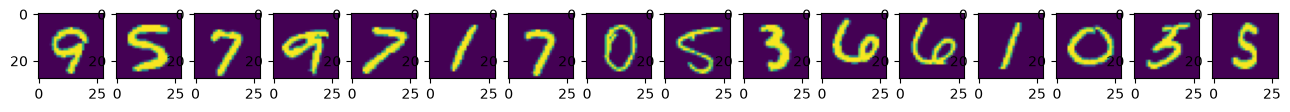

In [21]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

test_dataset = datasets.MNIST(root="../data", download=True, train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

test_features, test_labels = next(iter(test_loader))

# plot the images
fig, axs = plt.subplots(nrows=1, ncols=16, figsize=(16, 1))

for i, splt in enumerate(axs):
    splt.imshow(test_features[i].reshape(28, 28))

### Run inference by invoking the Azure function URL

The Azure function endpoint URL is of the format `function_app.azurewebsites.net`. We send the input to the function in the json format

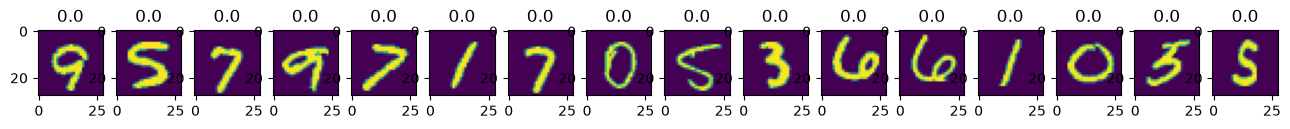

In [22]:
import requests
import json
import numpy as np


def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()


url = f"https://{function_app}.azurewebsites.net/api/classify"
if AZURE_CONNECTED:
    response = requests.post(url, json.dumps({"data": to_numpy(test_features).tolist()}))
    predictions = json.loads(response.text)["digits"]
else:
    predictions = np.zeros(test_features.size(0))
# plot the images
fig_out, axs_out = plt.subplots(nrows=1, ncols=16, figsize=(16, 1))

for i, splt in enumerate(axs_out):
    splt.imshow(test_features[i].reshape(28, 28))
    splt.set_title(predictions[i])

## Clean Up

After we have tested that our model is running successfully on Azure function app, we delete the resources to avoid incurring unnecessary costs

In [23]:
if AZURE_CONNECTED:
    !az group delete --name {resource_group_name} --yes

## Conclusion

In this notebook, we used prebuilt docker images with Amazon SageMaker to train an PyTorch model and deploy it to Azure

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.


![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/deploy_and_monitor|sm-multi_cloud_deployment_with_onnx|pytorch|mnist-train-using-pytorch.ipynb)
